In [20]:
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and data science tools
import scipy as sp
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split  # Example common import
# Note: You usually import specific modules from scikit-learn (e.g., from sklearn.ensemble import RandomForestClassifier)

In [19]:
import sys
print(sys.executable) # Data manipulation and analysis


c:\Dev\Week-3-KAIM-Insurance-Risk-Review-Challenge\.venv\Scripts\python.exe


In [5]:
df = pd.read_csv("../data/insurance_data.csv")
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [6]:
df.shape

(10000, 21)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  str    
 16

# Data Type Conversion
Converting TransactionDate into datetime format for temporal analysis.

In [8]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           10000 non-null  str           
 1   Age                  10000 non-null  int64         
 2   Gender               10000 non-null  str           
 3   Province             10000 non-null  str           
 4   VehicleType          10000 non-null  str           
 5   AnnualIncome         10000 non-null  int64         
 6   RiskScore            10000 non-null  int64         
 7   AnnualPremium        10000 non-null  int64         
 8   Deductible           10000 non-null  int64         
 9   NCD                  10000 non-null  int64         
 10  PastClaims           10000 non-null  int64         
 11  Claimed              10000 non-null  bool          
 12  ClaimAmount          10000 non-null  float64       
 13  TotalPremium         10000 non-null  int64 

## 2. Data Quality Assessment

In [10]:
missing_values = df.isnull().sum()

missing_values

CustomerID             0
Age                    0
Gender                 0
Province               0
VehicleType            0
AnnualIncome           0
RiskScore              0
AnnualPremium          0
Deductible             0
NCD                    0
PastClaims             0
Claimed                0
ClaimAmount            0
TotalPremium           0
TotalClaims            0
CoverType              0
AutoMake               0
VehicleModel           0
CustomValueEstimate    0
ZipCode                0
TransactionDate        0
dtype: int64

### Observation
The dataset contains no missing values across all columns. 
This indicates strong data completeness and reduces the need for aggressive imputation or row removal strategies.

## 3. Descriptive Statistics

In [11]:
df.describe()

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode,TransactionDate
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050,2024-09-29 14:52:22.080000
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000,2024-01-01 00:00:00
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000,2024-05-18 00:00:00
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000,2024-09-29 00:00:00
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000,2025-02-11 00:00:00
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000,2025-06-29 00:00:00
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245,NaN


In [12]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,46.6835,16.717963,18.0,32.00,46.0,61.0,75.0
AnnualIncome,10000.0,79201.9739,33039.939770,17202.0,56105.00,72942.0,95092.0,376916.0
RiskScore,10000.0,58.1400,14.267486,15.0,48.00,57.0,67.0,95.0
AnnualPremium,10000.0,2488.1279,735.674491,951.0,2028.00,2307.0,2676.0,5105.0
Deductible,10000.0,751.7000,500.509401,250.0,500.00,500.0,1000.0,2000.0
NCD,10000.0,20.9350,14.549122,0.0,10.00,20.0,30.0,50.0
PastClaims,10000.0,1.0642,1.051945,0.0,0.00,1.0,2.0,5.0
ClaimAmount,10000.0,1314.1885,3921.864903,0.0,0.00,0.0,0.0,49623.0
TotalPremium,10000.0,2488.1279,735.674491,951.0,2028.00,2307.0,2676.0,5105.0
TotalClaims,10000.0,1314.1885,3921.864903,0.0,0.00,0.0,0.0,49623.0


In [13]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

In [14]:
overall_loss_ratio = df["TotalClaims"].sum() / df["TotalPremium"].sum()

overall_loss_ratio

np.float64(0.5281836596904845)

In [15]:
province_loss = df.groupby("Province")["LossRatio"].mean().sort_values(ascending=False)

province_loss

Province
Somali         0.523516
Oromia         0.452680
Tigray         0.438639
Addis Ababa    0.436347
Amhara         0.395941
Name: LossRatio, dtype: float64

In [16]:
vehicle_loss = df.groupby("VehicleType")["LossRatio"].mean().sort_values(ascending=False)

vehicle_loss

VehicleType
Luxury       0.803672
SUV          0.499749
Hatchback    0.370846
Sedan        0.348758
Name: LossRatio, dtype: float64

In [17]:
gender_loss = df.groupby("Gender")["LossRatio"].mean()

gender_loss

Gender
Female    0.447351
Male      0.437929
Name: LossRatio, dtype: float64

## 4. Univariate Analysis

In [18]:
important_numerical = [
    "AnnualIncome",
    "AnnualPremium",
    "ClaimAmount",
    "TotalClaims",
    "CustomValueEstimate"
]

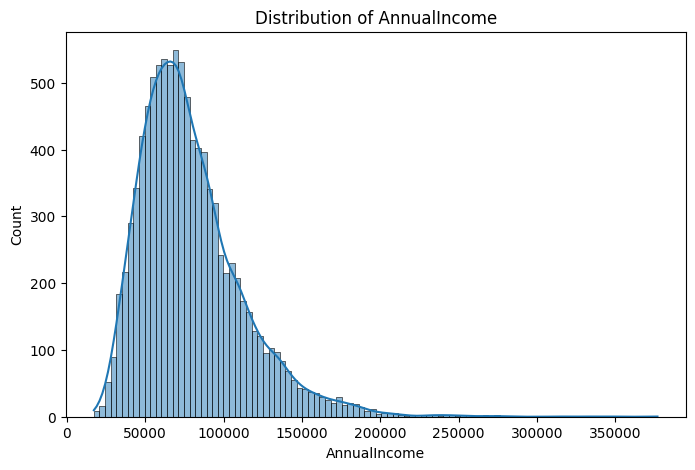

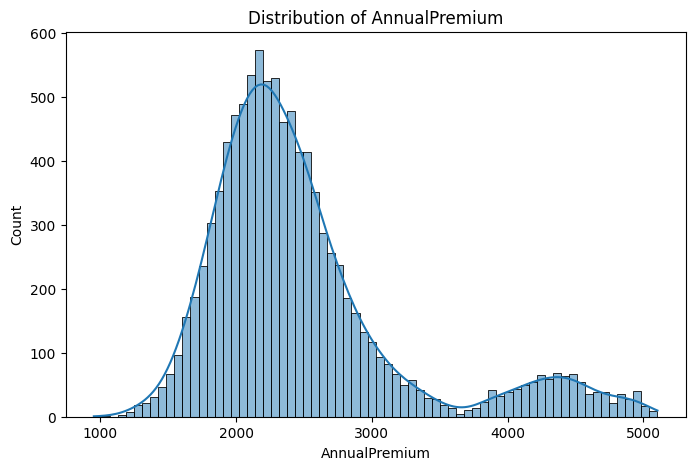

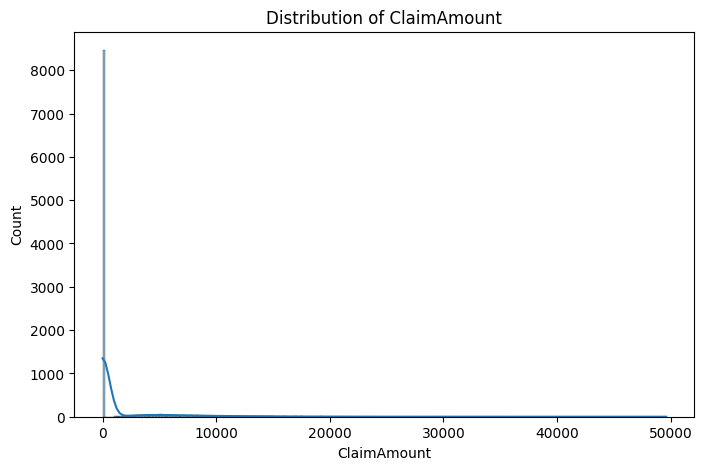

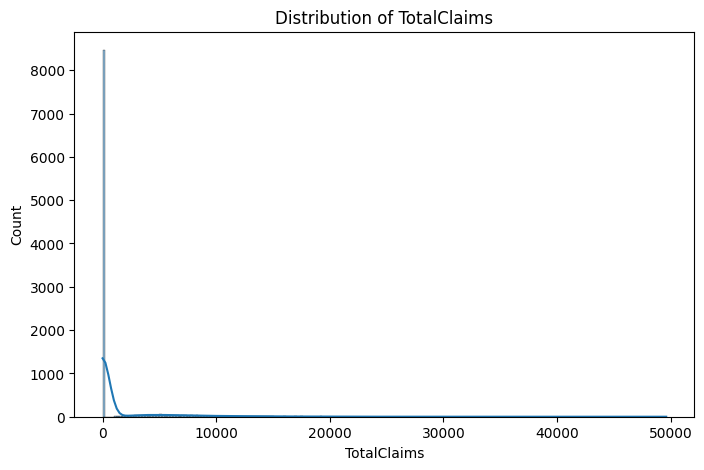

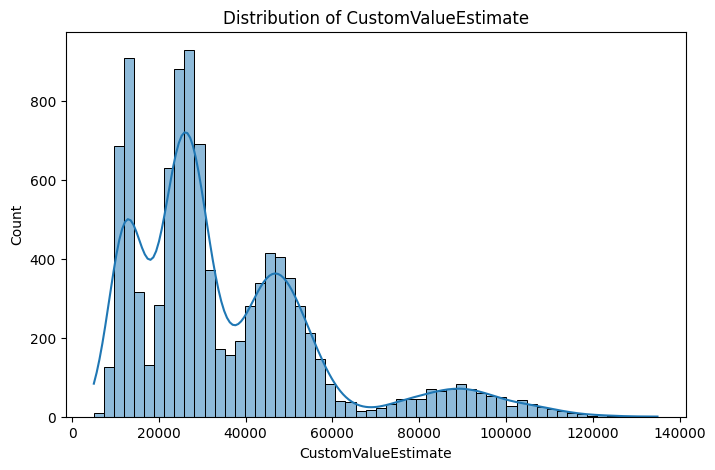

In [21]:
for col in important_numerical:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Categorical Analysis

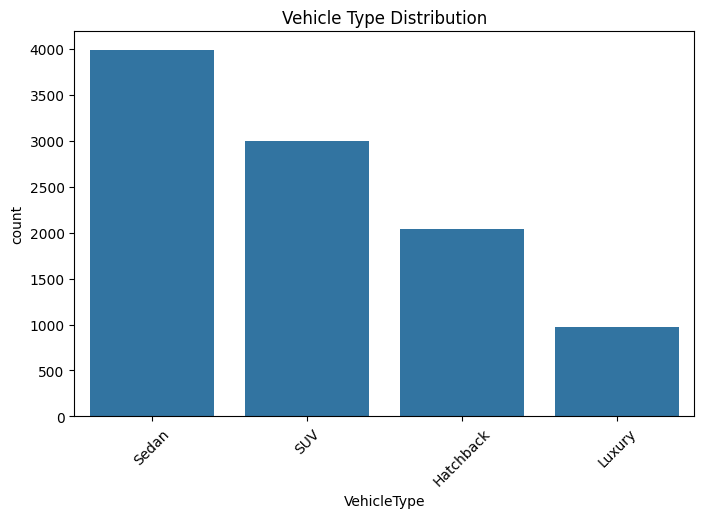

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="VehicleType")

plt.xticks(rotation=45)

plt.title("Vehicle Type Distribution")

plt.show()

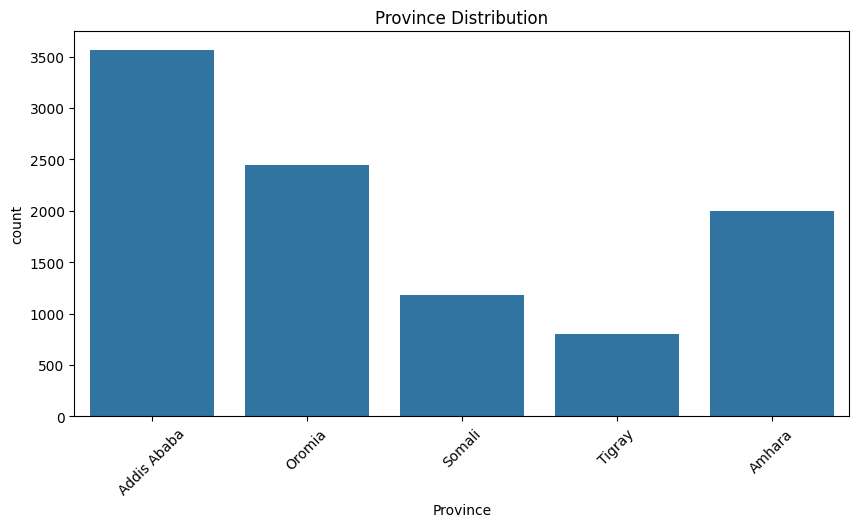

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Province")

plt.xticks(rotation=45)

plt.title("Province Distribution")

plt.show()

## 5. Bivariate & Multivariate Analysis

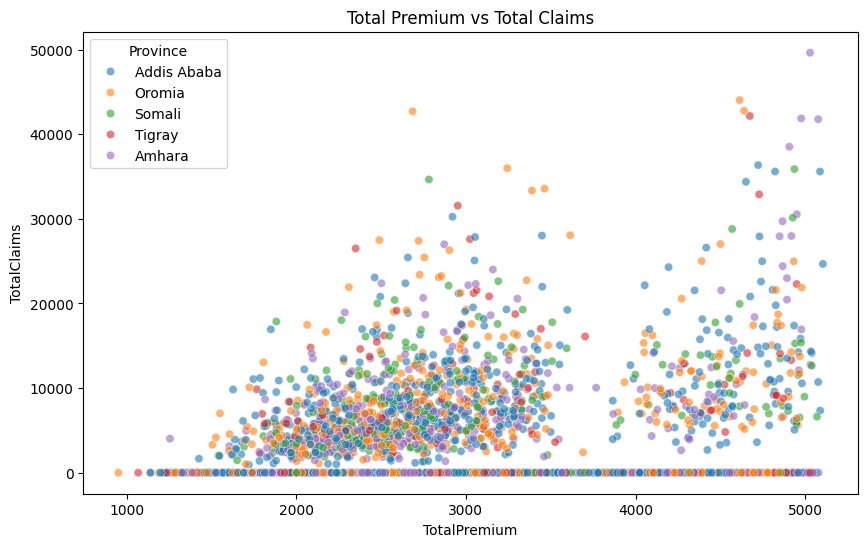

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    hue="Province",
    alpha=0.6
)

plt.title("Total Premium vs Total Claims")

plt.show()

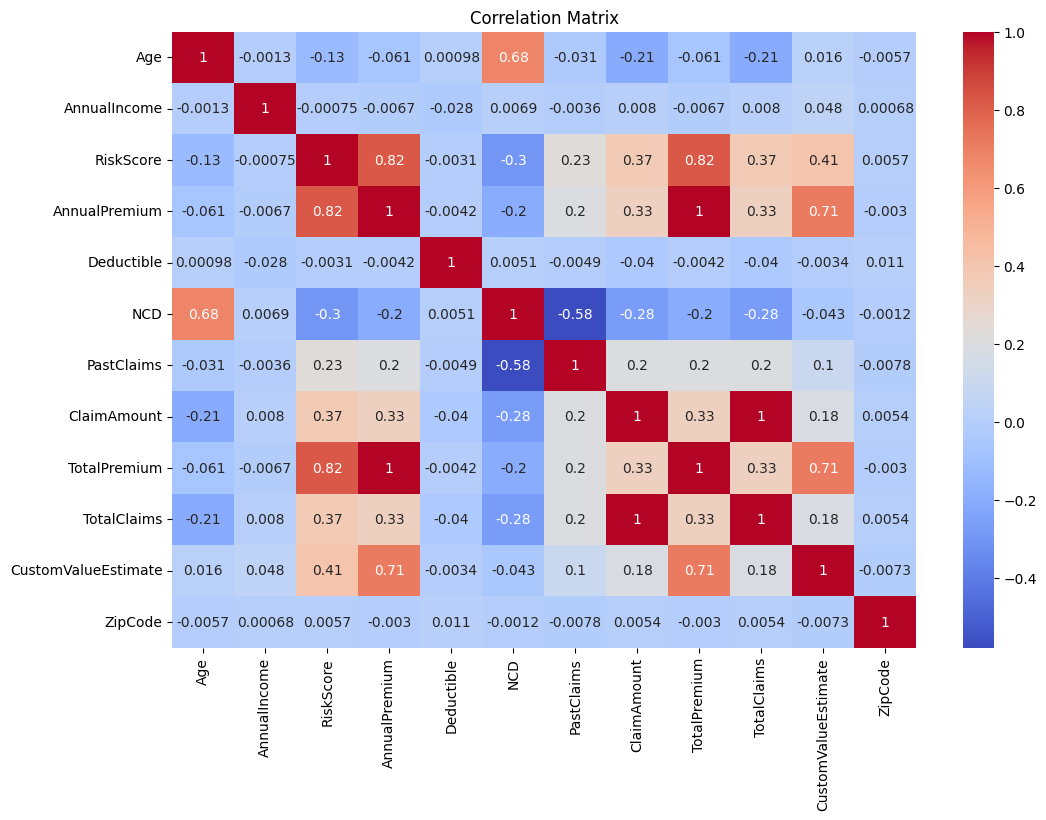

In [25]:
plt.figure(figsize=(12,8))

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()



## 6. Geographic Trends

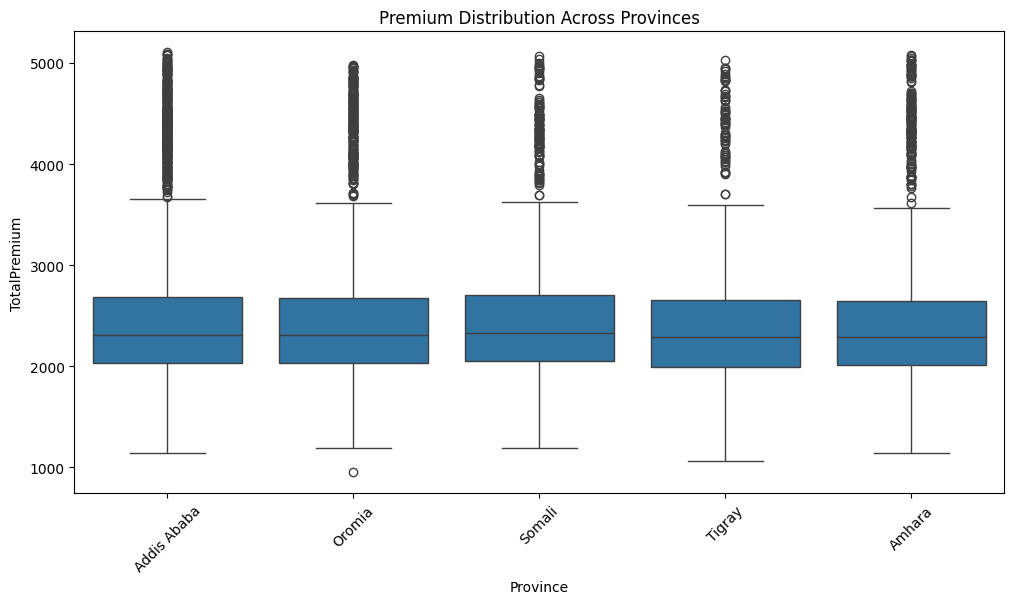

In [26]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="Province", y="TotalPremium")

plt.xticks(rotation=45)

plt.title("Premium Distribution Across Provinces")

plt.show()

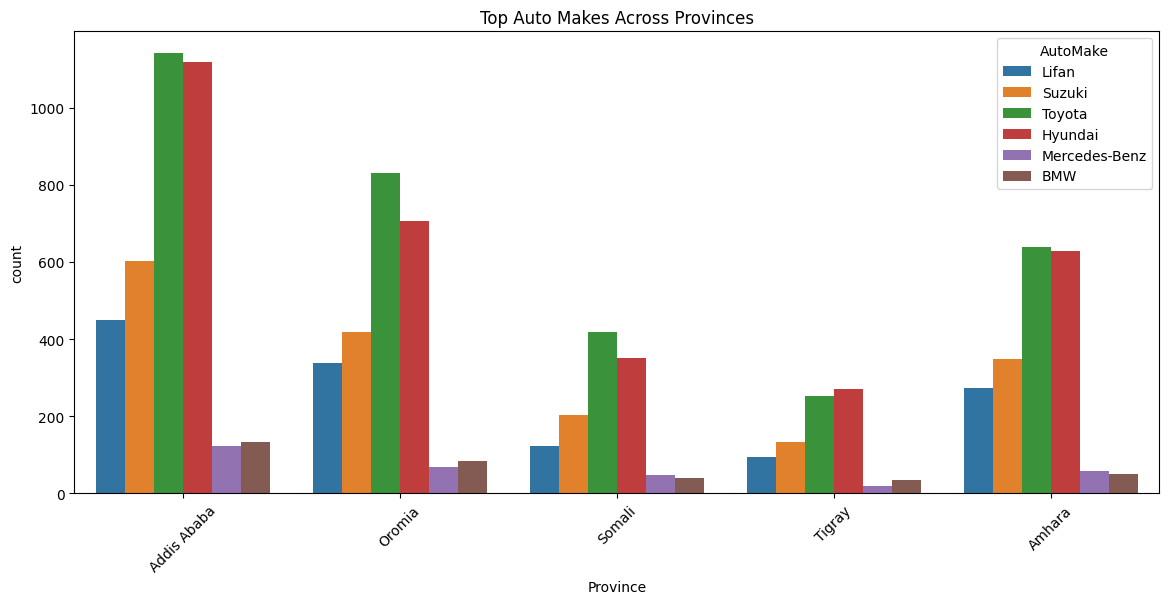

In [27]:
plt.figure(figsize=(14,6))

top_makes = df["AutoMake"].value_counts().head(10).index

filtered = df[df["AutoMake"].isin(top_makes)]

sns.countplot(data=filtered, x="Province", hue="AutoMake")

plt.xticks(rotation=45)

plt.title("Top Auto Makes Across Provinces")

plt.show()



## 7. Outlier Detection

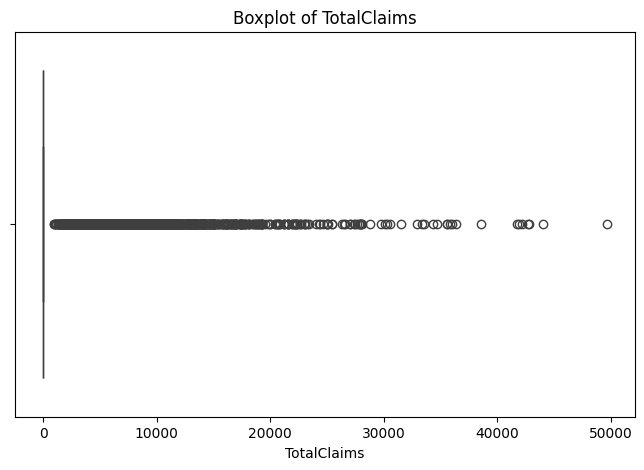

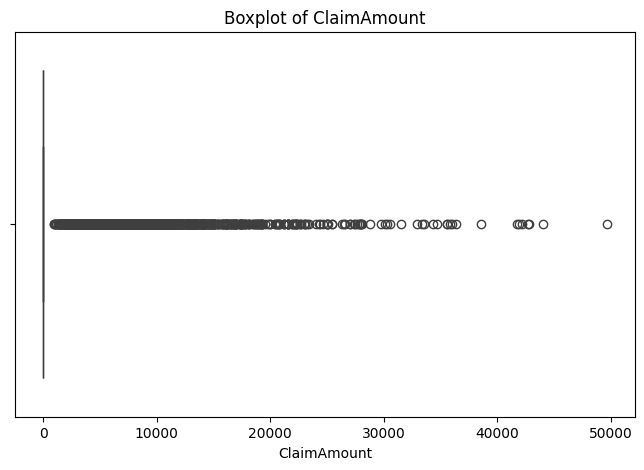

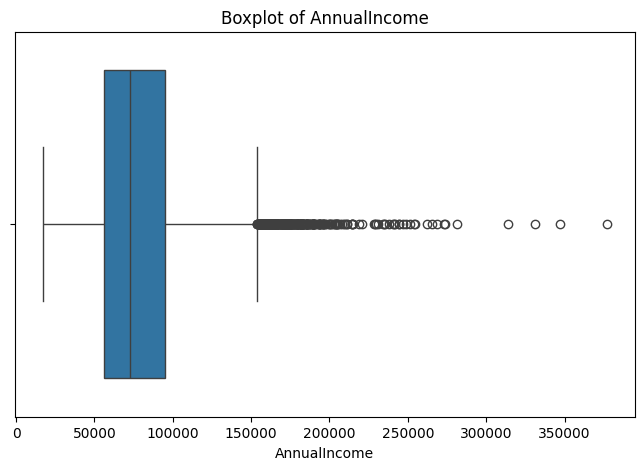

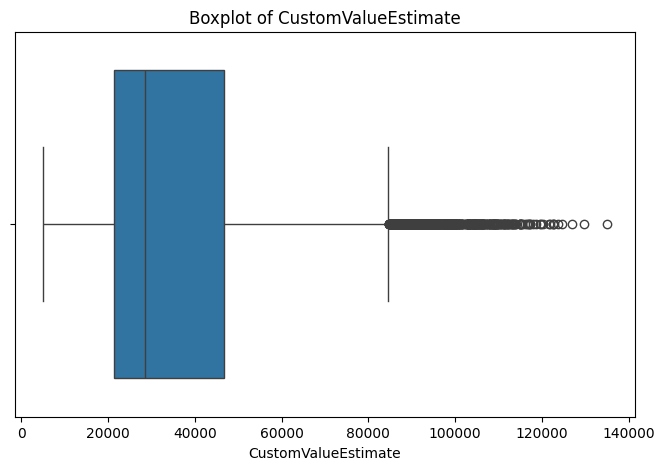

In [28]:
outlier_cols = [
    "TotalClaims",
    "ClaimAmount",
    "AnnualIncome",
    "CustomValueEstimate"
]

for col in outlier_cols:
    plt.figure(figsize=(8,5))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

## Temporal trends

In [29]:
df["Month"] = df["TransactionDate"].dt.to_period("M")

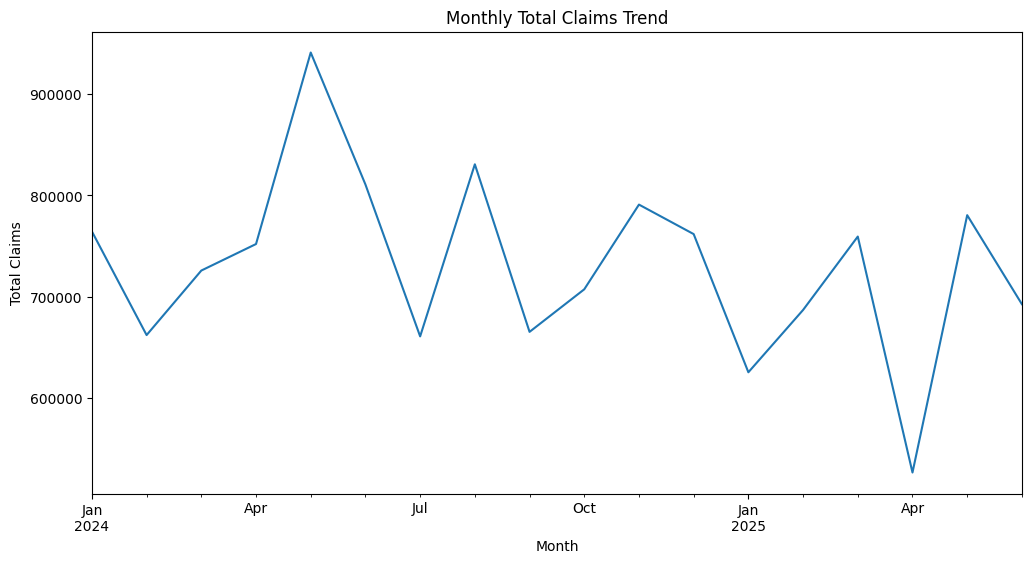

In [30]:
monthly_claims = df.groupby("Month")["TotalClaims"].sum()

monthly_claims.plot(figsize=(12,6))

plt.title("Monthly Total Claims Trend")

plt.ylabel("Total Claims")

plt.show()

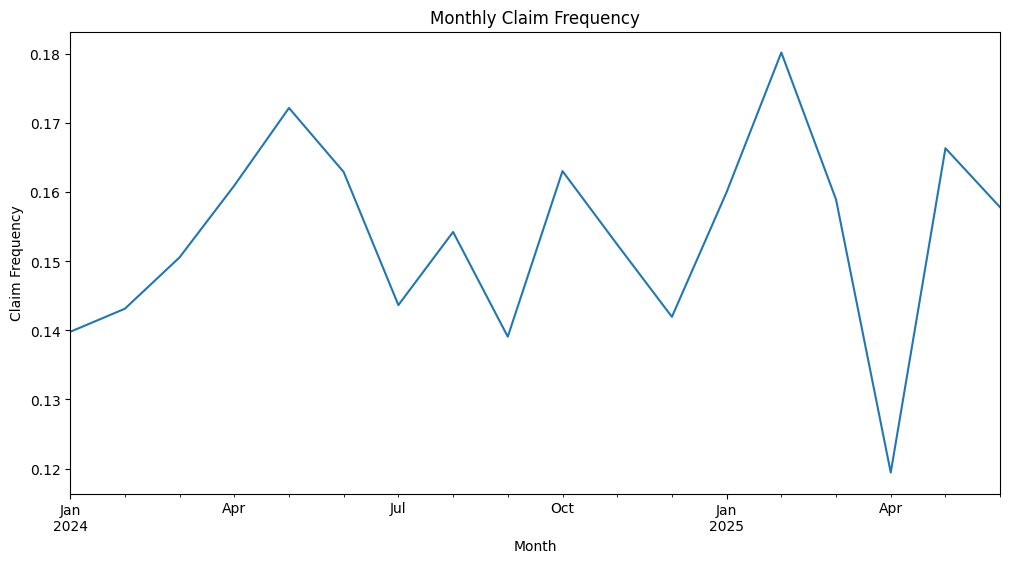

In [31]:
monthly_frequency = df.groupby("Month")["Claimed"].mean()

monthly_frequency.plot(figsize=(12,6))

plt.title("Monthly Claim Frequency")

plt.ylabel("Claim Frequency")

plt.show()

In [32]:
vehicle_claims = df.groupby("VehicleModel")["TotalClaims"].mean().sort_values()

In [33]:
vehicle_claims.head(10)

VehicleModel
Elantra          810.128870
Swift            834.459644
620              918.103987
Vitz             946.650238
Corolla          965.448640
i10             1033.730769
Grand Vitara    1337.185261
Tucson          1368.343225
RAV4            1384.229249
5 Series        3362.890855
Name: TotalClaims, dtype: float64

In [34]:
vehicle_claims.tail(10)

VehicleModel
620              918.103987
Vitz             946.650238
Corolla          965.448640
i10             1033.730769
Grand Vitara    1337.185261
Tucson          1368.343225
RAV4            1384.229249
5 Series        3362.890855
E-Class         3787.012618
Land Cruiser    3888.303797
Name: TotalClaims, dtype: float64

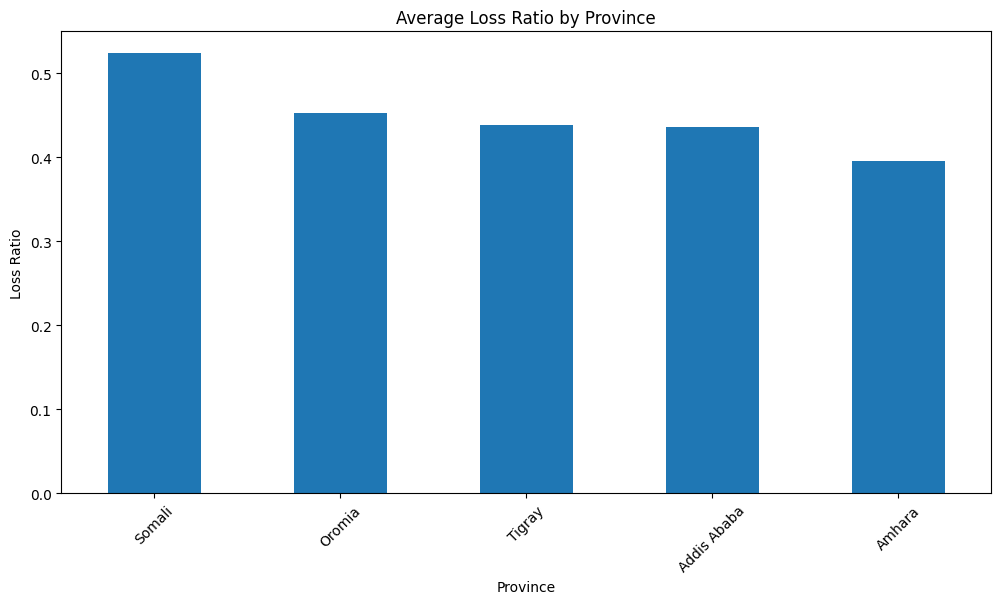

In [35]:
plt.figure(figsize=(12,6))

province_loss.plot(kind="bar")

plt.title("Average Loss Ratio by Province")

plt.ylabel("Loss Ratio")

plt.xticks(rotation=45)

plt.show()

In [36]:
cleaned_df = df.copy()

In [37]:
cleaned_df.to_csv("../data/insurance_data_cleaned.csv", index=False)